# **Programa Especializado en Credit Scoring con Python**
<img src="../../figuras/logo.png" width="200"/>

## 📊 **Sesión 14: Interpretabilidad y Explicabilidad de Modelos.**

**Docente**: Enzo Infantes Zúñiga  
**Contacto**: <enzo.infantes28@gmail.com>  
**LinkedIn**: [enzo-infantes](https://www.linkedin.com/in/enzo-infantes/)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import ptitprince as pt
import seaborn as sns
import math
import sys
import os
import joblib
import warnings
from scipy.stats import randint, uniform

from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import lightgbm as lgb
from sklearn.model_selection import (RandomizedSearchCV, GridSearchCV, StratifiedKFold, cross_val_score)
from sklearn.metrics import (roc_auc_score, roc_curve, auc, confusion_matrix, classification_report, ConfusionMatrixDisplay)

import shap
from sklearn.inspection import PartialDependenceDisplay

warnings.filterwarnings("ignore")

absolute_path = os.path.dirname(os.path.dirname(os.getcwd()))
data_path = os.path.join(absolute_path, "data", "s10")
model_path = os.path.join(absolute_path, "models")
figure_path = os.path.join(absolute_path, "figuras", "s14")

SEED = 42
np.random.seed(SEED)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

print(f'   SHAP version: {shap.__version__}')
print(f'   XGBoost version: {xgb.__version__}')

   SHAP version: 0.51.0
   XGBoost version: 3.2.0


**Contexto**: ¿Por qué necesitamos Interpretabilidad en Credit Scoring?

En la Sesión 13 comparamos modelos usando métricas de discriminación (AUC, Gini, KS) y métricas de estabilidad (PSI, CV-AUC). Seleccionamos al **Logistic Regression** (o XGBoost) como el mejor modelo en términos predictivos. Sin embargo, tener un modelo con un AUC alto **no es suficiente** en el entorno bancario.

# **1. Introducción**
## **1.1 El Dilema: Precisión vs. Interpretabilidad**

```
  ALTA INTERPRETABILIDAD          ALTA PRECISIÓN
  ─────────────────────────────────────────────────
  Reglas simples                  Redes Neuronales
  Regresión Logística (WOE)       XGBoost / LightGBM
  Árboles de Decisión simples     Random Forest
  ─────────────────────────────────────────────────
    "Caja Blanca"                "Caja Negra"
```

En credit scoring, los modelos de **caja negra** presentan limitaciones en tres dimensiones:

### **1.2 Dimensiones del Problema**
**Regulación:**
- Bajo **Basilea II/III**, los bancos deben demostrar que sus modelos son comprensibles y auditables.
- La **GDPR** (Europa) y normativas locales exigen explicar decisiones automatizadas a clientes rechazados (**"right to explanation"**).
- La **SBS** (Perú), **SBIF/CMF** (Chile), **Banco de México**, etc., requieren que los modelos sean validados y documentados.

**Comité de Riesgos:**
- El Directorio y el Comité de Créditos no aprueban modelos que no pueden entender.
- Un modelo inexplicable genera desconfianza aunque tenga métricas superiores.

**Operación y Monitoreo:**
- Si un modelo produce resultados inesperados, necesitamos entender *por qué* para poder corregirlo.
- La interpretabilidad permite detectar *sesgo* (e.g., género, raza implícita) y *data leakage*.

### **1.3 La Solución: Explainable Artificial Intelligence (XAI)**
El campo de **XAI** busca mantener el poder predictivo de modelos complejos **sin sacrificar la capacidad de explicar sus decisiones**. Las técnicas más usadas en la industria son:

| Técnica | Tipo | Alcance |
|---------|------|----------|
| Feature Importance (Gain/Cover) | Nativa del modelo | Global |
| **SHAP** (SHapley Additive exPlanations) | Agnóstica al modelo | Global + Local |
| PDP (Partial Dependence Plots) | Agnóstica al modelo | Global |
| ICE (Individual Conditional Expectation) | Agnóstica al modelo | Local |
| LIME | Agnóstica al modelo | Local |

# **2. Carga de Datos**

### 2.1 Dataset Simulado de Crédito

In [2]:
X_train = pd.read_csv(os.path.join(data_path, 'X_train_proc.csv'))
X_test  = pd.read_csv(os.path.join(data_path, 'X_test_proc.csv'))
X_val   = pd.read_csv(os.path.join(data_path, 'X_val_proc.csv'))
y_train = pd.read_csv(os.path.join(data_path, 'y_train.csv'))
y_test  = pd.read_csv(os.path.join(data_path, 'y_test.csv'))
y_val   = pd.read_csv(os.path.join(data_path, 'y_val.csv'))

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"X_val shape: {X_val.shape}")

print(f"y_train defaul rate: {y_train['DEFAULT'].mean()*100:.2f}")
print(f"y_test defaul rate: {y_test['DEFAULT'].mean()*100:.2f}")
print(f"y_val defaul rate: {y_val['DEFAULT'].mean()*100:.2f}")

X_train shape: (17341, 24)
X_test shape: (7875, 24)
X_val shape: (4784, 24)
y_train defaul rate: 22.38
y_test defaul rate: 22.60
y_val defaul rate: 22.49


In [3]:
X_train.set_index("MES_STR", inplace=True)
X_test.set_index("MES_STR", inplace=True)
X_val.set_index("MES_STR", inplace=True)

# **3. Carga de Modelos**

**1. XGBoost** (eXtreme Gradient Boosting) fue introducido por Chen & Guestrin en 2016 y se convirtió en el algoritmo dominante en competencias de datos.

**Características**
- **Regularización integrada** (L1 y L2) que controla el overfitting.
- Manejo eficiente de **valores nulos** (los aprende directamente).
- **Poda inteligente** de árboles (*pruning*) basada en ganancia.
- Soporte para **class_weight** y métricas personalizadas.

`learning_rate` bajo + `n_estimators` alto → mejor generalización, pero mayor tiempo de entrenamiento. En la práctica, se recomienda `learning_rate ≤ 0.1` con early stopping.


**2. Regresión Logística**
La Regresión Logística es una herramienta de modelado adecuada y estadísticamente robusta para determinar la **Probabilidad de Default**.

**Características**
- **Modelo Supervisado** -> La variable target está definida (historia)
- **Problema de Clasificación** -> GOOD or BAD | YES or NO (Y no es continua)
- **Sigmoid Function** -> Función de Distribución Logística (u = 0 y desv = 1)


In [4]:
model_lr  = joblib.load(os.path.join(model_path, 's13', 'modelo_lr.pkl'))
model_xgb = joblib.load(os.path.join(model_path, 's12', 'modelo_xgb.pkl'))

print("Modelos cargados: LogisticRegression y XGBoost")

Modelos cargados: LogisticRegression y XGBoost


# **4. Feature Importance Tradicional**

Revisamos los métodos nativos de cada modelo para medir la importancia de las variables. Estos son más simples pero tienen limitaciones importantes.

1. **COEFICIENTES DE REGRESIÓN LOGÍSTICA**: Los coeficientes representan el cambio en el log-odds por cada unidad de la variable (estandarizada). Un coeficiente positivo → mayor riesgo.

In [5]:
features = X_train.columns.tolist() 
print(features)

['EDAD', 'NIVEL_EDUCATIVO', 'NUM_DEPENDIENTES', 'TIPO_EMPLEO', 'ANTIGUEDAD_LABORAL', 'TIPO_CREDITO', 'PLAZO_MESES', 'TASA_INTERES', 'NUM_CREDITOS_PREVIOS', 'DIAS_MORA_MAX', 'RATIO_UTILIZACION', 'TIPO_VIVIENDA', 'RATIO_LTV', 'IND_INGRESO_MISSING', 'IND_HISTORIAL_MISSING', 'CASADO', 'HOMBRE', 'CUOTA_ESTIMADA', 'RATIO_ENDEUDAMIENTO', 'SEGMENTO_RIESGO', 'INTERACCION_EDAD_MORA', 'LOG_INGRESO_MENSUAL', 'LOG_MONTO_CREDITO']


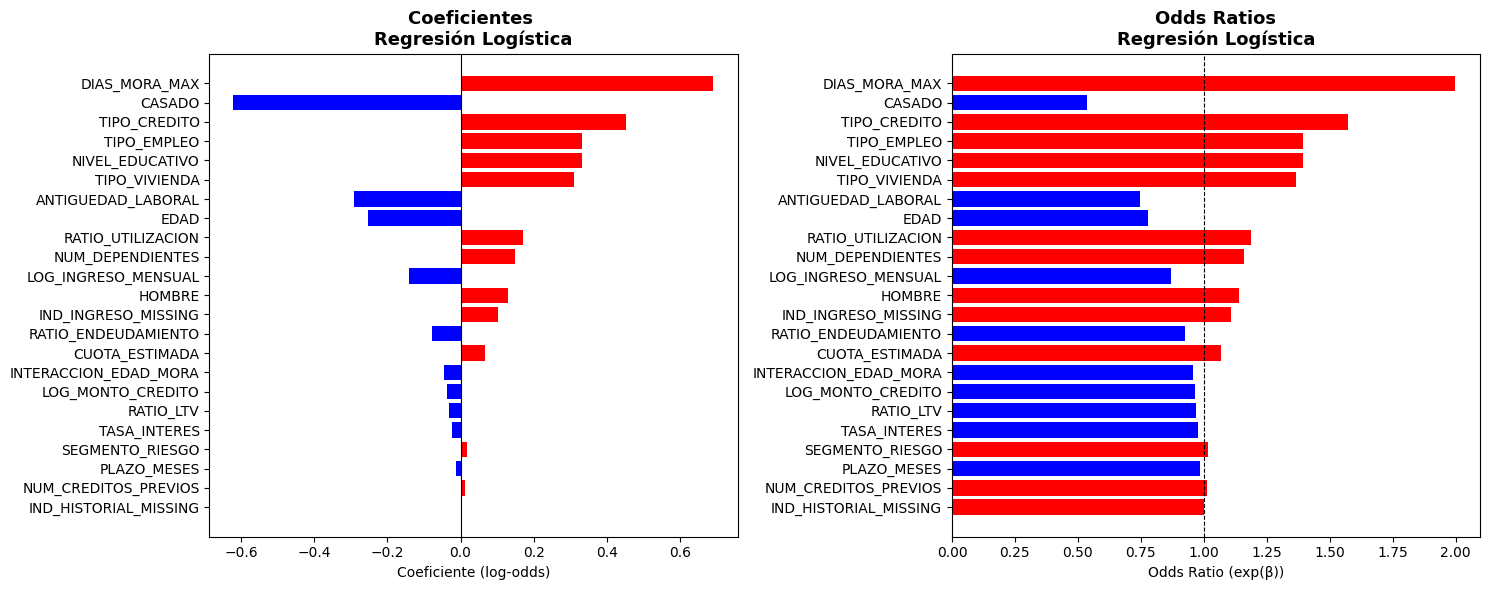


 Interpretación de Odds Ratios:
   OR > 1 → La variable AUMENTA la probabilidad de default
   OR < 1 → La variable REDUCE  la probabilidad de default


In [6]:
coef_df = pd.DataFrame({
    'Variable': features,
    'Coeficiente': model_lr.coef_[0],
    'Odds_Ratio': np.exp(model_lr.coef_[0])
}).sort_values('Coeficiente', key=abs, ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Coeficientes
colors = ['red' if v > 0 else 'blue' for v in coef_df['Coeficiente']]
axes[0].barh(coef_df['Variable'], coef_df['Coeficiente'], color=colors)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Coeficientes \nRegresión Logística', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Coeficiente (log-odds)')

# Odds Ratios
colors_or = ['red' if v > 1 else 'blue' for v in coef_df['Odds_Ratio']]
axes[1].barh(coef_df['Variable'], coef_df['Odds_Ratio'], color=colors_or)
axes[1].axvline(1, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Odds Ratios\nRegresión Logística', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Odds Ratio (exp(β))')

plt.tight_layout()
plt.savefig('../../figuras/s14/s14_coeficientes_lr.png', bbox_inches='tight')
plt.show()

print('\n Interpretación de Odds Ratios:')
print('   OR > 1 → La variable AUMENTA la probabilidad de default')
print('   OR < 1 → La variable REDUCE  la probabilidad de default')

**Gráfico 1**
- Por cada **día adicional de mora**, el *log-odds* de incumplimiento aumenta en 0.7. Como es el valor positivo más alto en tu gráfico, es el predictor principal de riesgo en tu modelo.

**Gráfico 2**
- Por cada unidad que aumenta **DIAS_MORA_MAX**, la probabilidad (u odds) de que el cliente caiga en impago se duplica.

2. **FEATURE IMPORTANCE NATIVA DE XGBOOST**: XGBoost ofrece 3 métricas distintas de importancia:
- weight  : número de veces que la variable se usa para dividir - cuántas veces el modelo le preguntó algo a esa variable.
- gain    : mejora promedio en la función objetivo al usar la variable - cuando el modelo usa esa variable, la precisión del veredicto mejora drásticamente.
- cover   : número promedio de observaciones cubiertas por la variable - qué tan "popular" o general es la variable en la muestra.

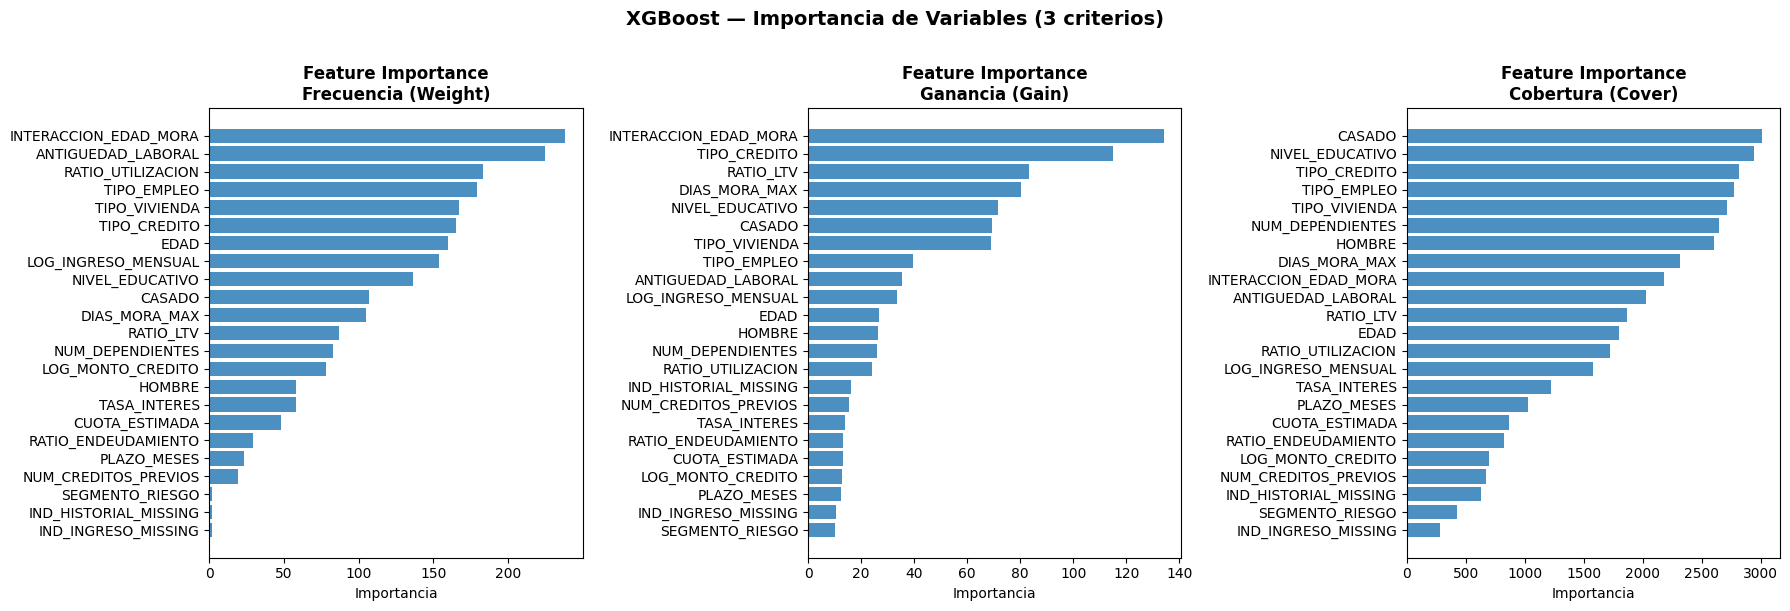

In [7]:
importance_types = ['weight', 'gain', 'cover']
labels_types     = ['Frecuencia (Weight)', 'Ganancia (Gain)', 'Cobertura (Cover)']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, imp_type, label in zip(axes, importance_types, labels_types):
    imp = model_xgb.get_booster().get_score(importance_type=imp_type)
    imp_df = pd.DataFrame([{'Variable': features[features.index(k)], 'Importancia': 
                            v} for k, v in imp.items()]).sort_values('Importancia', ascending=True)
    
    ax.barh(imp_df['Variable'], imp_df['Importancia'], color='#2C7BB6', alpha=0.85)
    ax.set_title(f'Feature Importance\n{label}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Importancia')

plt.suptitle('XGBoost — Importancia de Variables (3 criterios)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../../figuras/s14/s14_feature_importance_xgb.png', bbox_inches='tight')
plt.show()

**Conclusiones de Negocio por Variable**

| Variable                                  | Fortaleza        | Conclusión de Negocio |
|-------------------------------------------|------------------|-----------------------|
| Interacción Edad–Mora–                    | Ganancia + Frecuencia   | Es el predictor #1. El riesgo depende de la madurez del cliente frente a sus atrasos.s . |
| Tipo de Crédito                           | Ganancia Máxima  | Es el “tiro de gracia”. Define el perfil de riesgo con muy pocas preguntas. |
| Estado Civil (Casado)                     | Cobertura Total  | Es un filtro general. No decide el caso por sí solo, pero aplica a casi toda la cartera. toda la cartera. |

# **5. Introducción a SHAP (SHapley Additive exPlanations)**

## **5.1 Origen: Teoría de Juegos Cooperativos**

SHAP fue propuesto por **Lundberg & Lee (2017)** y se basa en los **valores de Shapley**, un concepto de teoría de juegos cooperativos desarrollado por Lloyd Shapley en 1953 (Premio Nobel de Economía 2012).

**Analogía:** Imagina que un equipo de futbolistas gana un premio de 100,000 dólares. ¿Cómo repartir el premio de manera *justa* según la contribución de cada jugador?

La solución de Shapley es: la recompensa justa para cada jugador es la **contribución marginal** que aporta al equipo, calculado como un promedio de todas las combinaciones posibles en las que pudo haber jugado.



## **5.2 SHAP en Machine Learning (Idea Intuitiva)**

En Machine Learning, SHAP responde a una pregunta simple:

> **¿Cuánto aporta cada variable a la predicción final?**

La idea es la siguiente:

- Partimos de una **predicción base**:  
  lo que el modelo predice *en promedio* para todos los datos.
- Luego, cada variable **ajusta** esa predicción:
  - algunas la suben
  - otras la bajan
- El valor **SHAP** mide exactamente **cuánto empuja cada variable**.

Formalmente, SHAP calcula ese aporte comparando la predicción:
- **con la variable**
- **sin la variable**
en distintos contextos, y promedia el efecto de forma justa.

**Interpretación clave**:  
El valor SHAP de una variable es su **contribución promedio y justa** a la predicción.


## **5.3 Propiedad Fundamental de SHAP**

$$
f(x) = \mathbb{E}[f(x)] + \sum_{i=1}^{p} \phi_i
$$

### Intuición

La predicción del modelo se descompone como:

- $\mathbb{E}[f(x)]$
  → Predicción base (*qué esperaría el modelo sin información individual*)

- $\phi_i$
  → Aporte de cada variable a esa predicción

**Idea clave**:

$$
\text{Predicción final}
=
\text{Predicción base}
+
\text{Aportes de las variables}
$$

Esto hace que SHAP sea tan útil:  
cada predicción se puede **explicar como una suma de efectos claros e interpretables**.

**¿Por qué SHAP es tan poderoso?**
- La descomposición es **exacta**
- Es **consistente** (si una variable importa más en el modelo, su SHAP no disminuye)
- Hace interpretables **predicciones individuales**, no solo el modelo completo

## **5.4 Propiedades que Garantiza SHAP**

| Propiedad | Descripción |
|-----------|-------------|
| **Eficiencia** | La suma de los SHAP values = predicción - valor base |
| **Simetría** | Variables con igual contribución reciben igual SHAP value |
| **Dummy** | Variables sin efecto reciben SHAP value = 0 |
| **Aditividad** | Los SHAP values de modelos combinados se pueden sumar |

> El valor de Shapley es el promedio de cuánto mejora el resultado final cada vez que un jugador (o variable) se une a diferentes grupos de compañeros."

In [8]:
# =============================================================================
# EXPLICABILIDAD SHAP PARA REGRESIÓN LOGÍSTICA
# =============================================================================

# 1. Configuración del "Detective" (Explainer)
# El LinearExplainer es un motor que descompone el modelo lineal en sus partes básicas.
# Usamos X_train como referencia para que el modelo sepa qué es un valor "normal".
explainer_lr = shap.LinearExplainer(
    model_lr, 
    X_train,
    feature_perturbation='correlation_dependent' # Considera la relación entre variables (evita conclusiones falsas)
)

# 2. Cálculo de Impactos (Valores SHAP)
# Aquí calculamos los "empujones" individuales para cada una de las 7,875 personas del test.
# Cada valor SHAP dice: "¿Cuánto riesgo sumó o restó ESTA variable a ESTA persona?"
shap_values_lr = explainer_lr(X_test)

print(f'   SHAP values calculados para Regresión Logística')
print(f'   Shape: {shap_values_lr.values.shape}  (observaciones × variables)')

# 3. El Punto de Partida (Valor Base)
# Es el riesgo promedio de la cartera. Sin mirar al cliente, este es su score inicial.
# En log-odds, un valor negativo significa baja probabilidad de default.
print(f'   Valor base (E[f(x)]): {shap_values_lr.base_values[0]:.4f} log-odds')

print('\n     Verificación de la "Propiedad de Eficiencia" (Observación 0):')

# A. EL CAMINO DEL MODELO (El veredicto del Juez)
# Le pedimos al modelo su predicción final. Como sale en probabilidad (0.1, 0.5, etc.), 
# la convertimos a "log-odds" (logit) para poder sumar y restar linealmente.
obs0_pred   = model_lr.predict_proba(X_test[:1])[:, 1][0]
obs0_logit  = np.log(obs0_pred / (1 - obs0_pred))

# B. EL CAMINO DE SHAP (La suma de las partes)
# Tomamos el "Punto de Partida" y le sumamos TODOS los "empujones" de las variables.
# Si SHAP es correcto, la suma de los pedazos debe dar el total del modelo.
obs0_shap   = shap_values_lr.base_values[0] + shap_values_lr.values[0].sum()

# C. LA COMPROBACIÓN FINAL
# Si la diferencia es 0, hemos demostrado que el modelo es 100% transparente.
print(f'   Predicción modelo (log-odds) : {obs0_logit:.4f}')
print(f'   Base + Σ SHAP values          : {obs0_shap:.4f}')

# Una diferencia de 0.000000 significa que no hay "magia" ni errores:
# Cada punto de riesgo tiene una explicación asignada a una variable específica.
print(f'   Diferencia                    : {abs(obs0_logit - obs0_shap):.6f}')

Estimating transforms:   0%|          | 0/1000 [00:00<?, ?it/s]

   SHAP values calculados para Regresión Logística
   Shape: (7875, 23)  (observaciones × variables)
   Valor base (E[f(x)]): -0.3359 log-odds

     Verificación de la "Propiedad de Eficiencia" (Observación 0):
   Predicción modelo (log-odds) : -0.5664
   Base + Σ SHAP values          : -0.5664
   Diferencia                    : 0.000000


📝 **Interpretación de la Verificación SHAP**

* **Efecto de las variables:** El Cliente 0 tiene un riesgo final de **-0.5664**, un valor más bajo que el promedio global (**-0.3359**). Esto indica que sus características personales predominantes son "factores protectores".
* **Propiedad de Eficiencia:** La diferencia de **0.000000** confirma que la suma de las contribuciones individuales (SHAP values) equivale exactamente a la predicción del modelo.
* **Conclusión:** El modelo de Regresión Logística es **totalmente transparente y auditable**. Podemos desglosar el score de cualquier cliente en sus componentes básicos sin pérdida de información.

**IMPORTANCIA GLOBAL**

$\text{mean}(|\text{SHAP value}|)$.

SHAP Value: Es el valor promedio de cada variable → importancia global

- Fuerza de la Variable: Indica cuántas unidades (en escala log-odds) mueve esa variable a la predicción final, en promedio.
- Factores Críticos: El TIPO_VIVIENDA (0.36) y el TIPO_CREDITO (0.35) son los motores principales del modelo. Cambiar estos valores tiene un impacto drástico en el score del cliente.

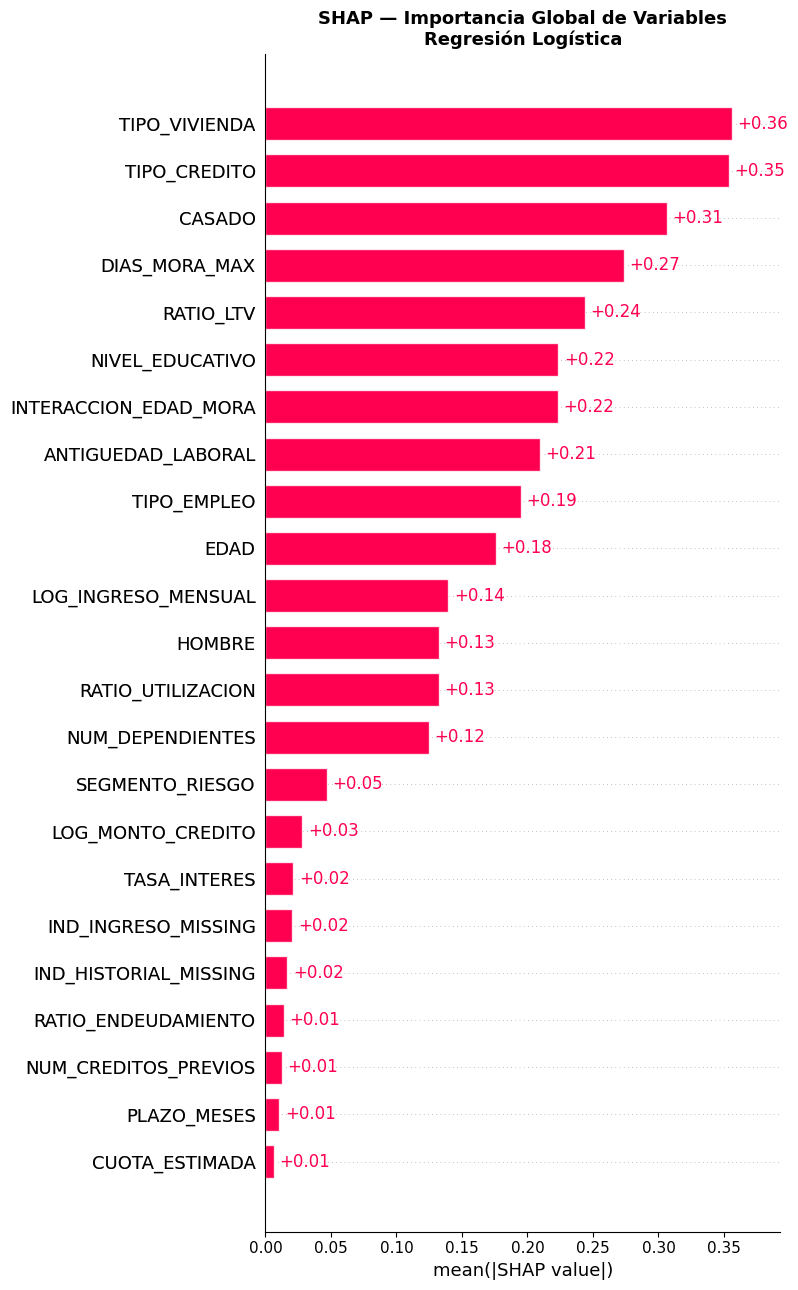

In [9]:
plt.figure(figsize=(9, 5))
shap.plots.bar(shap_values_lr, max_display=25, show=False)
plt.title('SHAP — Importancia Global de Variables\nRegresión Logística', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../../figuras/s14/s14_shap_bar_lr.png', bbox_inches='tight')
plt.show()

El beeswarm plot es el gráfico más informativo de SHAP.
- Cada punto = una observación.
- Eje X = valor SHAP (contribución al log-odds).
- Color = valor real de la variable (azul=bajo, rojo=alto).

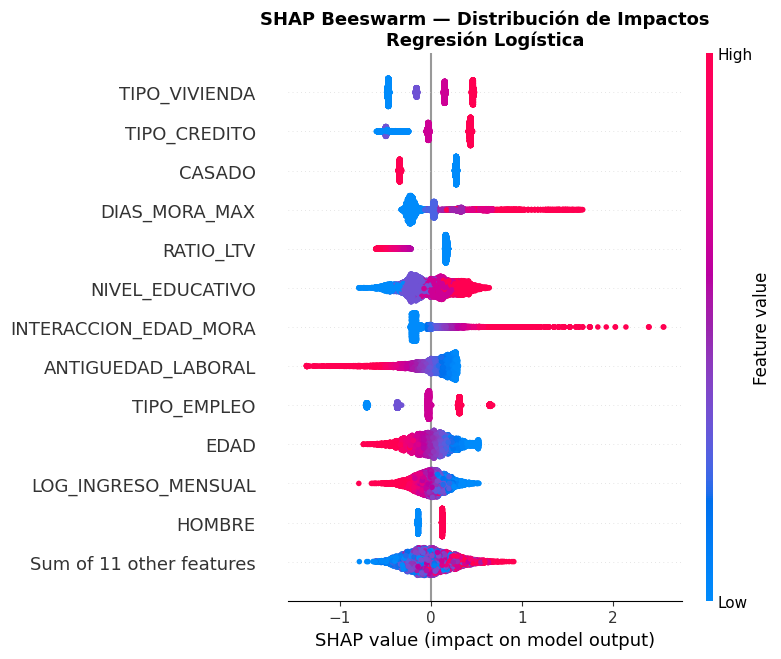

    Cómo leer el Beeswarm:
   • Cada fila = una variable
   • Cada punto = una observación del conjunto de test
   • SHAP > 0 → la variable AUMENTA la probabilidad de default
   • SHAP < 0 → la variable REDUCE  la probabilidad de default
   • Puntos rojos = valores altos de la variable
   • Puntos azules = valores bajos de la variable


In [10]:
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values_lr, max_display=13, show=False)
plt.title('SHAP Beeswarm — Distribución de Impactos\nRegresión Logística', 
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../../figuras/s14/s14_shap_beeswarm_lr.png', bbox_inches='tight')
plt.show()

print('    Cómo leer el Beeswarm:')
print('   • Cada fila = una variable')
print('   • Cada punto = una observación del conjunto de test')
print('   • SHAP > 0 → la variable AUMENTA la probabilidad de default')
print('   • SHAP < 0 → la variable REDUCE  la probabilidad de default')
print('   • Puntos rojos = valores altos de la variable')
print('   • Puntos azules = valores bajos de la variable')

**XGBoost**

TreeExplainer es el más eficiente para modelos basados en árboles

In [11]:
import shap.explainers._tree as _shap_tree
original_init_code = _shap_tree.XGBTreeModelLoader.__init__

def _safe_patched_init(self, xgb_model):
    import json
    config = json.loads(xgb_model.save_config())
    param  = config["learner"]["learner_model_param"]
    raw    = param.get("base_score", "0.5")
    
    # Solo modificar si tiene corchetes
    if raw.startswith("[") and raw.endswith("]"):
        param["base_score"] = raw[1:-1]  # quitar [ y ]
        xgb_model.load_config(json.dumps(config))
    
    # Llamar al original SIN pasar por el patch de nuevo
    original_init_code(self, xgb_model)

# Solo parchear si aún no fue parcheado (evitar doble patch entre celdas)
if _shap_tree.XGBTreeModelLoader.__init__.__name__ != '_safe_patched_init':
    _shap_tree.XGBTreeModelLoader.__init__ = _safe_patched_init
    print("✅ Patch aplicado correctamente")
else:
    print("ℹ️  Patch ya estaba aplicado")

✅ Patch aplicado correctamente


In [12]:
explainer_xgb = shap.TreeExplainer(
    model_xgb,
    data=X_train,
    model_output='probability'
)
shap_values_xgb = explainer_xgb(X_test)

print(f'   SHAP values calculados para XGBoost')
print(f'   Shape      : {shap_values_xgb.values.shape}')
print(f'   Valor base : {shap_values_xgb.base_values[0]:.4f}')

obs0_pred_xgb = model_xgb.predict_proba(X_test.iloc[:1])[:, 1][0]
obs0_shap_xgb = shap_values_xgb.base_values[0] + shap_values_xgb.values[0].sum()
print(f'\n Verificación (obs 0):')
print(f'   Predicción modelo : {obs0_pred_xgb:.4f}')
print(f'   Base + Σ SHAP     : {obs0_shap_xgb:.4f}')
print(f'   Diferencia        : {abs(obs0_pred_xgb - obs0_shap_xgb):.6f}')

 99%|===================| 7835/7875 [00:32<00:00]        

   SHAP values calculados para XGBoost
   Shape      : (7875, 23)
   Valor base : 0.4273

 Verificación (obs 0):
   Predicción modelo : 0.3986
   Base + Σ SHAP     : 0.3986
   Diferencia        : 0.000000


**Feature Importance Tradicional vs. SHAP**

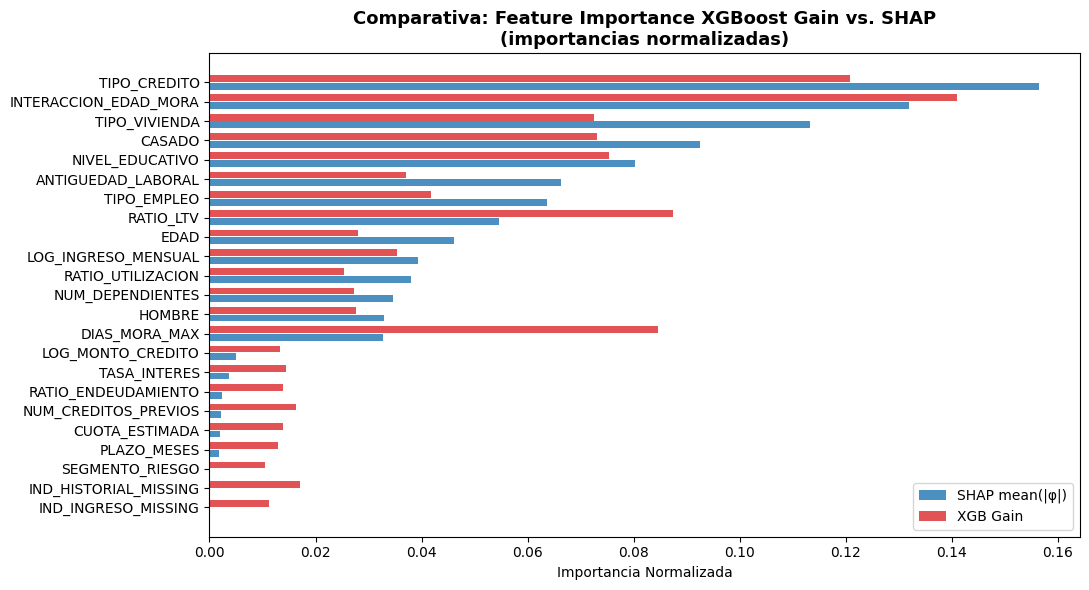

In [13]:
# SHAP mean(|φ|) — importancia global
shap_importance = pd.DataFrame({
    'Variable': features,
    'SHAP_mean_abs': np.abs(shap_values_xgb.values).mean(axis=0)
}).sort_values('SHAP_mean_abs', ascending=False)

# XGBoost Gain
gain_imp = model_xgb.get_booster().get_score(importance_type='gain')
gain_df  = pd.DataFrame([
    {'Variable': features[features.index(k)], 'Gain': v}
    for k, v in gain_imp.items()
])

compare_df = shap_importance.merge(gain_df, on='Variable', how='left').fillna(0)
compare_df['SHAP_norm'] = compare_df['SHAP_mean_abs'] / compare_df['SHAP_mean_abs'].sum()
compare_df['Gain_norm'] = compare_df['Gain'] / compare_df['Gain'].sum()
compare_df = compare_df.sort_values('SHAP_norm', ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))
y_pos = np.arange(len(compare_df))
ax.barh(y_pos - 0.2, compare_df['SHAP_norm'], 0.35, label='SHAP mean(|φ|)', color='#2C7BB6', alpha=0.85)
ax.barh(y_pos + 0.2, compare_df['Gain_norm'],  0.35, label='XGB Gain',       color='#D7191C', alpha=0.75)
ax.set_yticks(y_pos)
ax.set_yticklabels(compare_df['Variable'])
ax.set_xlabel('Importancia Normalizada')
ax.set_title('Comparativa: Feature Importance XGBoost Gain vs. SHAP\n(importancias normalizadas)', 
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../../figuras/s14/s14_shap_vs_gain.png', bbox_inches='tight')
plt.show()

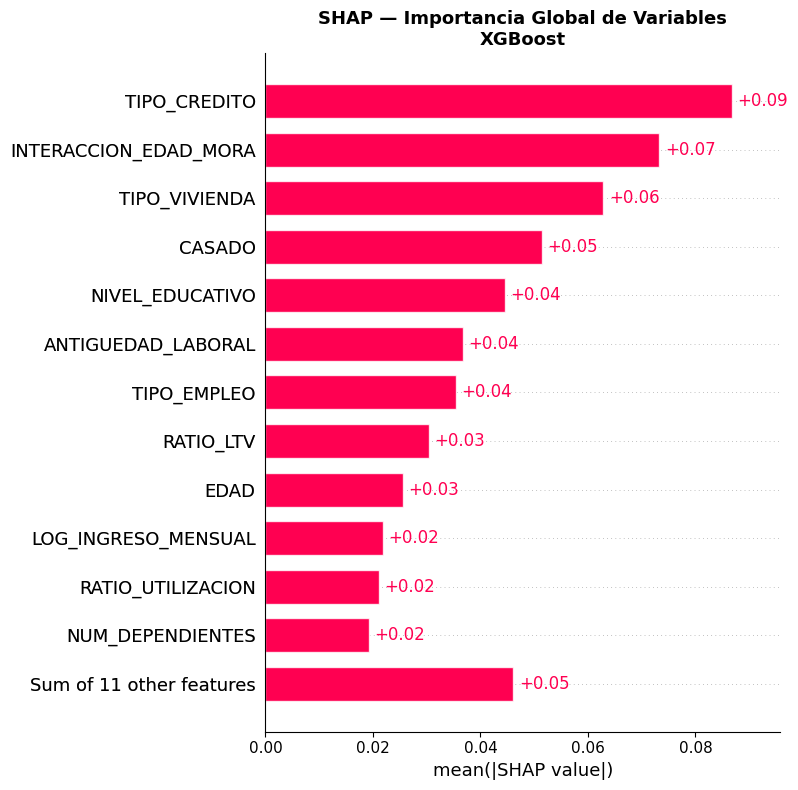

In [14]:
plt.figure(figsize=(9, 5))
shap.plots.bar(shap_values_xgb, max_display=13, show=False)
plt.title('SHAP — Importancia Global de Variables\nXGBoost', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**🔍 Diferencias entre Importancia SHAP y Gain de XGBoost**

Es normal observar que los valores numéricos y las longitudes de las barras no coinciden exactamente entre gráficos debido a dos factores:

1.  **Escala vs. Porcentaje:** * El gráfico de **SHAP Bar** muestra valores en **log-odds** (unidades reales de impacto en la predicción). 
    * El gráfico **Comparativo** muestra **importancias normalizadas** (proporción del 0% al 100%) para permitir una comparación visual directa entre métricas distintas.

2.  **Atribución Local vs. Global:**
    * **XGBoost Gain:** Mide la mejora en el entrenamiento del modelo. Es muy sensible a variables que segmentan grandes grupos de datos rápidamente.
    * **SHAP:** Mide la contribución a la predicción final. Es una métrica más balanceada que considera las interacciones entre variables, lo que ofrece una visión más "humana" y justa de la importancia.

**Conclusión:** No es que los valores no conversen, es que están hablando en diferentes idiomas (unidades reales vs. porcentajes). El **orden (ranking)** de las variables es lo que realmente debemos validar para asegurar la consistencia del modelo.

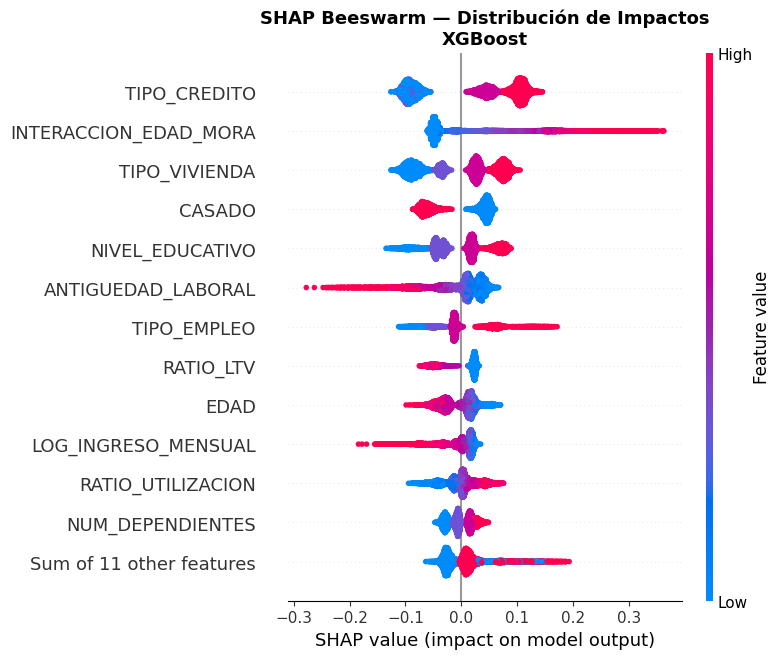

In [15]:
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values_xgb, max_display=13, show=False)
plt.title('SHAP Beeswarm — Distribución de Impactos\nXGBoost', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../../figuras/s14/s14_shap_beeswarm_xgb.png', bbox_inches='tight')
plt.show()

In [ ]:
top6_vars = shap_importance.head(6)['Variable'].tolist()
top6_idx  = [features.index(v) for v in top6_vars]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes_flat = axes.flatten()

for ax, var_name, var_idx in zip(axes_flat, top6_vars, top6_idx):
    x_vals  = shap_values_xgb.data[:, var_idx]
    y_vals  = shap_values_xgb.values[:, var_idx]
    
    scatter = ax.scatter(x_vals, y_vals, c=y_vals, cmap='RdBu_r',
                         alpha=0.4, s=8, vmin=-0.2, vmax=0.2)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    
    # Línea de tendencia
    from numpy.polynomial.polynomial import polyfit
    x_sorted = np.sort(x_vals)
    coefs = np.polyfit(x_vals, y_vals, deg=3)
    y_fit = np.polyval(coefs, x_sorted)
    ax.plot(x_sorted, y_fit, color='black', linewidth=1.5)
    
    ax.set_xlabel(var_name, fontsize=10)
    ax.set_ylabel('SHAP value', fontsize=9)
    ax.set_title(f'Efecto de: {var_name}', fontsize=11, fontweight='bold')
    plt.colorbar(scatter, ax=ax, label='SHAP', fraction=0.04)

plt.suptitle('SHAP Dependence Plots — Relación Variable × Impacto\nXGBoost',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../../figuras/s14/s14_shap_dependence_top6.png', bbox_inches='tight')
plt.show()

print('📋 Qué buscar en los Dependence Plots:')
print('   • Relaciones NO LINEALES (curvas, umbrales, mesetas)')
print('   • El punto donde el SHAP cruza cero = umbral de riesgo neutro')
print('   • Dispersión vertical a mismo X = efecto de interacciones')

# **6. Ideas Finales**


| Audiencia | Mensaje |  Herramienta SHAP |
|-----------|---------|--------------------|
| **Directorio** | ¿Qué variables impulsan el riesgo? | Beeswarm Plot |
| **Comité de Créditos** | ¿Por qué se rechazó a este cliente? | Waterfall / Force Plot |
| **Riesgo / Auditoría** | ¿El modelo tiene sesgos? ¿Es estable? | Dependence Plots + PSI |
| **Regulador** | ¿El modelo es explicable y auditable? | Feature Importance + SHAP |
| **Tecnología** | ¿Cómo implementamos la explicación? | SHAP values en API |


**P: ¿Por qué usamos XGBoost y no una regresión logística?**  
R: El XGBoost captura relaciones no lineales e interacciones entre variables, lo que resulta en un AUC superior. Mediante SHAP, mantenemos la capacidad de explicar cada decisión.

**P: ¿Cómo sabemos que el modelo no discrimina por factores prohibidos?**  
R: Podemos calcular los SHAP values segmentados por grupo demográfico para verificar que variables como género o etnicidad no tienen impacto significativo.

**P: ¿Qué pasa si el modelo se equivoca? ¿Podemos auditarlo?**  
R: Para cualquier predicción, podemos generar un reporte SHAP que descompone exactamente qué variables llevaron a esa decisión.

**P: ¿El modelo es estable en el tiempo?**  
R: Esto fue abordado en la Sesión 13 mediante el PSI y CV-AUC. El PSI < 0.10 indica estabilidad de la distribución de scores.